# Multiple Tools [Step 3 - Parallel Calls, Tool Selection & Fallback Chains]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how an LLM selects and uses multiple tools.
We build an agent with calculator, string utils, and datetime tools,
showing parallel tool calls, tool selection, and fallback chains.

## 1. Setup and Imports

In [1]:
import os
import math
import json
import datetime
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
load_dotenv()

False

## 2. Initialize the LLM

In [2]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("LLM initialized:", llm.model)

LLM initialized: llama3.1:8b


## 3. Define Calculator Tools

In [3]:
from langchain_core.tools import tool

@tool
def add(a: float, b: float) -> float:
    """Add two numbers together. Returns the sum of a and b."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers. Returns the product of a and b."""
    return a * b

@tool
def power(base: float, exponent: float) -> float:
    """Raise base to the power of exponent. Returns base ** exponent."""
    return base ** exponent

## 4. Define String Utility Tools

In [4]:
@tool
def reverse_string(text: str) -> str:
    """Reverse a string. Returns the input string reversed."""
    return text[::-1]

@tool
def word_count(text: str) -> int:
    """Count the number of words in a text string."""
    return len(text.split())

@tool
def to_uppercase(text: str) -> str:
    """Convert text to uppercase."""
    return text.upper()

@tool
def to_lowercase(text: str) -> str:
    """Convert text to lowercase."""
    return text.lower()

## 5. Define DateTime Tools

In [5]:
@tool
def current_datetime() -> str:
    """Get the current date and time."""
    now = datetime.datetime.now()
    return now.strftime("%Y-%m-%d %H:%M:%S (%A)")

@tool
def days_between(date1: str, date2: str) -> int:
    """Calculate the number of days between two dates. Format: YYYY-MM-DD."""
    try:
        d1 = datetime.datetime.strptime(date1, "%Y-%m-%d")
        d2 = datetime.datetime.strptime(date2, "%Y-%m-%d")
        return abs((d2 - d1).days)
    except ValueError as ex:
        return f"Error: {ex}. Use format YYYY-MM-DD."

@tool
def add_days(date_str: str, days: int) -> str:
    """Add a number of days to a date. Date format: YYYY-MM-DD. Returns the new date."""
    try:
        d = datetime.datetime.strptime(date_str, "%Y-%m-%d")
        result = d + datetime.timedelta(days=days)
        return result.strftime("%Y-%m-%d")
    except ValueError as ex:
        return f"Error: {ex}. Use format YYYY-MM-DD."

## 6. Package Tools by Category

In [6]:
calculator_tools = [add, multiply, power]
string_tools = [reverse_string, word_count, to_uppercase, to_lowercase]
datetime_tools = [current_datetime, days_between, add_days]

all_tools = calculator_tools + string_tools + datetime_tools
print(f"Total tools registered: {len(all_tools)}")
print(f"  Calculator: {[t.name for t in calculator_tools]}")
print(f"  String:     {[t.name for t in string_tools]}")
print(f"  DateTime:   {[t.name for t in datetime_tools]}")

Total tools registered: 10
  Calculator: ['add', 'multiply', 'power']
  String:     ['reverse_string', 'word_count', 'to_uppercase', 'to_lowercase']
  DateTime:   ['current_datetime', 'days_between', 'add_days']


## 7. Bind All Tools to the LLM

In [7]:
llm_with_tools = llm.bind_tools(all_tools)
print("All tools bound to LLM.")

All tools bound to LLM.


## 8. Build the Agent Graph

In [8]:
from langgraph.graph import StateGraph, MessagesState, END
from langgraph.prebuilt import ToolNode, tools_condition

def agent_node(state: MessagesState):
    """Call the LLM with the current messages."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

Build the graph with tool routing.

Multi-tool agent graph compiled.


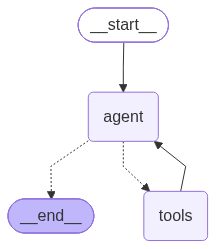

In [9]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", ToolNode(all_tools))
graph_builder.set_entry_point("agent")
graph_builder.add_conditional_edges("agent", tools_condition)
graph_builder.add_edge("tools", "agent")

graph = graph_builder.compile()
print("Multi-tool agent graph compiled.")

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  Entry -> agent")
    print("  agent -> [tools_condition] -> tools or END")
    print("  tools -> agent (loop)")

## 9. Test: Single Tool Selection (Calculator)

In [10]:
print("=== Test 1: Calculator - what is 5 + 3? ===")
result = graph.invoke({"messages": [{"role": "user", "content": "What is 5 + 3?"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Test 1: Calculator - what is 5 + 3? ===


  [HumanMessage]: What is 5 + 3?
  [AI] calls: add({'a': 5, 'b': 3})
  [Tool] (add): 8.0
  [AIMessage]: The answer to the question "What is 5 + 3?" is 8.


## 10. Test: Single Tool Selection (String Utils)

In [11]:
print("=== Test 2: String - reverse 'hello world' ===")
result = graph.invoke({"messages": [{"role": "user", "content": "Reverse the string 'hello world'"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Test 2: String - reverse 'hello world' ===


  [HumanMessage]: Reverse the string 'hello world'
  [AI] calls: reverse_string({'text': 'hello world'})
  [Tool] (reverse_string): dlrow olleh
  [AIMessage]: The reversed string is: dlrow olleh


## 11. Test: Parallel Tool Calls
When the LLM identifies that multiple tools are needed for a single query,
it can emit multiple tool calls in one response. Both execute in parallel.

In [12]:
print("=== Test 3: Parallel calls - 7 * 8 AND reverse 'python' ===")
result = graph.invoke({"messages": [{"role": "user", "content": "Calculate 7 * 8 and also reverse the word 'python'"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Test 3: Parallel calls - 7 * 8 AND reverse 'python' ===


  [HumanMessage]: Calculate 7 * 8 and also reverse the word 'python'
  [AI] calls: multiply({'a': 7, 'b': 8})
  [AI] calls: reverse_string({'text': 'python'})
  [Tool] (multiply): 56.0
  [Tool] (reverse_string): nohtyp
  [AIMessage]: The result of the multiplication is 56 and the reversed word 'python' is 'nohtyp'.


## 12. Test: Multi-Tool Selection

In [13]:
print("=== Test 4: Multiple tool calls - 3 tools at once ===")
result = graph.invoke({"messages": [{"role": "user", "content": "What is 2 ** 10, how many words in 'the quick brown fox', and what time is it now?"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:300]}")

=== Test 4: Multiple tool calls - 3 tools at once ===


  [HumanMessage]: What is 2 ** 10, how many words in 'the quick brown fox', and what time is it now?
  [AI] calls: power({'base': '2', 'exponent': '10'})
  [AI] calls: word_count({'text': 'the quick brown fox'})
  [AI] calls: current_datetime({})
  [Tool] (power): 1024.0
  [Tool] (word_count): 4
  [Tool] (current_datetime): 2026-08-26 13:31:50 (Wednesday)
  [AIMessage]: The results are:

1. 2 ** 10 = 1024
2. There are 4 words in 'the quick brown fox'.
3. The current time is 2026-08-26 13:31:50 (Wednesday).


## 13. Test: DateTime Tool Selection

In [14]:
print("=== Test 5: DateTime - days between two dates ===")
result = graph.invoke({"messages": [{"role": "user", "content": "How many days are there between 2024-01-01 and 2024-12-31?"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:200]}")

=== Test 5: DateTime - days between two dates ===


  [HumanMessage]: How many days are there between 2024-01-01 and 2024-12-31?
  [AI] calls: days_between({'date2': '2024-12-31', 'date1': '2024-01-01'})
  [Tool] (days_between): 365
  [AIMessage]: There are 365 days between January 1, 2024 and December 31, 2024.


## 14. Test: Cross-Category Query

In [15]:
print("=== Test 6: Cross-category - string + calculator ===")
result = graph.invoke({"messages": [{"role": "user", "content": "Count the words in 'I love building AI agents with LangGraph' and then multiply that count by 100"}]})
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  [AI] calls: {tc['name']}({tc['args']})")
    elif hasattr(msg, "name") and msg.name:
        print(f"  [Tool] ({msg.name}): {msg.content}")
    else:
        content = msg.content if isinstance(msg.content, str) else str(msg.content)
        print(f"  [{role}]: {content[:300]}")

=== Test 6: Cross-category - string + calculator ===


  [HumanMessage]: Count the words in 'I love building AI agents with LangGraph' and then multiply that count by 100
  [AI] calls: word_count({'text': 'I love building AI agents with LangGraph'})
  [AI] calls: multiply({'a': '1', 'b': '100'})
  [Tool] (word_count): 7
  [Tool] (multiply): 100.0
  [AIMessage]: The word count of 'I love building AI agents with LangGraph' is 7, and multiplying that by 100 gives us 700.


## 15. Demonstrate Tool Selection Intelligence
The LLM picks the right tool based on the tool description and the user query.

In [16]:
print("=== Tool Selection Summary ===")
print("The LLM selects tools based on:")
print("  1. Tool name and description (from @tool docstrings)")
print("  2. User query semantics")
print("  3. Argument matching (parameter names and types)")
print()
print("Parallel execution:")
print("  - When multiple tools are needed, the LLM emits multiple tool_calls")
print("  - ToolNode executes them all in parallel")
print("  - Results are collected and returned to the agent")
print()
print("Fallback behavior:")
print("  - If no tool matches, the LLM responds directly")
print("  - If a tool errors, the error is returned as a tool message")
print("  - The LLM can then try a different tool or explain the error")

=== Tool Selection Summary ===
The LLM selects tools based on:
  1. Tool name and description (from @tool docstrings)
  2. User query semantics
  3. Argument matching (parameter names and types)

Parallel execution:
  - When multiple tools are needed, the LLM emits multiple tool_calls
  - ToolNode executes them all in parallel
  - Results are collected and returned to the agent

Fallback behavior:
  - If no tool matches, the LLM responds directly
  - If a tool errors, the error is returned as a tool message
  - The LLM can then try a different tool or explain the error


## 16. Inspect Tool Schemas

In [17]:
print("=== Tool Schemas (what the LLM sees) ===")
for t in all_tools:
    schema = t.get_input_schema()
    if hasattr(schema, "model_json_schema"):
        schema = schema.model_json_schema()
    elif hasattr(schema, "schema"):
        schema = schema.schema()
    elif not isinstance(schema, dict):
        try:
            schema = dict(schema) if schema else {}
        except Exception:
            schema = {}
    props = schema.get("properties", {})
    params = ", ".join(f"{k}: {v.get('type', '?')}" for k, v in props.items())
    print(f"  {t.name}({params}) - {t.description[:50]}")

=== Tool Schemas (what the LLM sees) ===
  add(a: number, b: number) - Add two numbers together. Returns the sum of a and
  multiply(a: number, b: number) - Multiply two numbers. Returns the product of a and
  power(base: number, exponent: number) - Raise base to the power of exponent. Returns base 
  reverse_string(text: string) - Reverse a string. Returns the input string reverse
  word_count(text: string) - Count the number of words in a text string.
  to_uppercase(text: string) - Convert text to uppercase.
  to_lowercase(text: string) - Convert text to lowercase.
  current_datetime() - Get the current date and time.
  days_between(date1: string, date2: string) - Calculate the number of days between two dates. Fo
  add_days(date_str: string, days: integer) - Add a number of days to a date. Date format: YYYY-


## Summary

Key takeaways:
- The LLM selects tools based on descriptions and query intent
- Parallel tool calls: multiple tools execute in one step
- Cross-category queries chain tools across categories
- ToolNode handles all execution and error propagation
- Fallback: if no tool matches, LLM responds directly